# Practical 04: Object Detection using CNN


In [1]:
# ============================================
# CELL 1 : IMPORT LIBRARIES
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [2]:
# ============================================
# CELL 2 : LOAD FASHION-MNIST DATASET
# ============================================

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Train Size:", len(train_dataset))
print("Test Size:", len(test_dataset))

Train Size: 60000
Test Size: 10000


In [3]:
# ============================================
# CELL 3 : CLASS LABELS
# ============================================

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print(classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


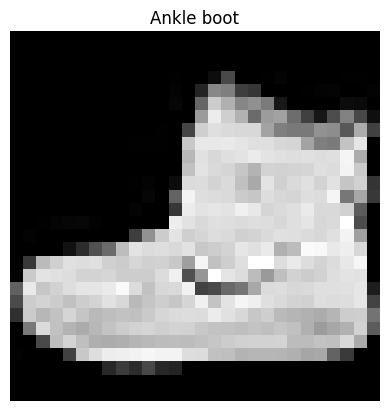

In [4]:
# ============================================
# CELL 4 : SHOW SAMPLE IMAGE
# ============================================

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap='gray')

plt.title(classes[label])

plt.axis('off')

plt.show()

In [5]:
# ============================================
# CELL 5 : CREATE DATALOADERS
# ============================================


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [6]:
# ============================================
# CELL 6 : DEFINE CNN MODEL
# ============================================

class FashionCNN(nn.Module):

    def __init__(self):

        super(FashionCNN, self).__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                1,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(
                32 * 7 * 7,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                10
            )
        )

    def forward(self, x):

        return self.network(x)


model = FashionCNN()

print(model)

FashionCNN(
  (network): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1568, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
# ============================================
# CELL 6 : DEFINE CNN MODEL
# ============================================

class FashionCNN(nn.Module):

    def __init__(self):

        super(FashionCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(
            32 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

    def forward(self, x):

        x = self.pool(
            self.relu(self.conv1(x))
        )

        x = self.pool(
            self.relu(self.conv2(x))
        )

        # Shape becomes:
        # batch_size x 32 x 7 x 7

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x


model = FashionCNN()

print(model)

FashionCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
# ============================================
# CELL 7 : TRAINING SETUP
# ============================================

device = torch.device(
    'mps' if torch.backends.mps.is_available() else 'cpu'
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Using Device:", device)

Using Device: mps


In [9]:
# ============================================
# CELL 8 : TRAIN MODEL
# ============================================

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch [1/5] Loss: 0.5329
Epoch [2/5] Loss: 0.3337
Epoch [3/5] Loss: 0.2856
Epoch [4/5] Loss: 0.2535
Epoch [5/5] Loss: 0.2298


In [10]:
# ============================================
# CELL 9 : TEST ACCURACY
# ============================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 89.04%


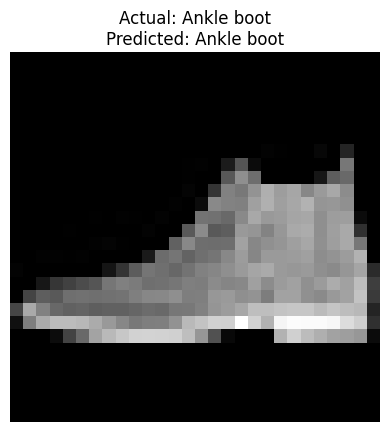

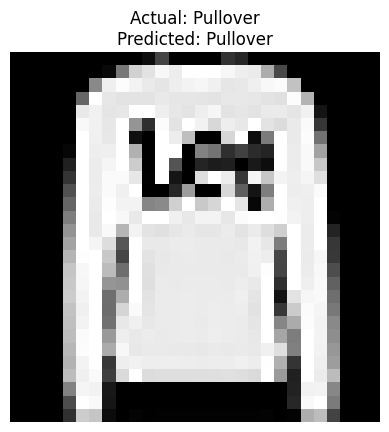

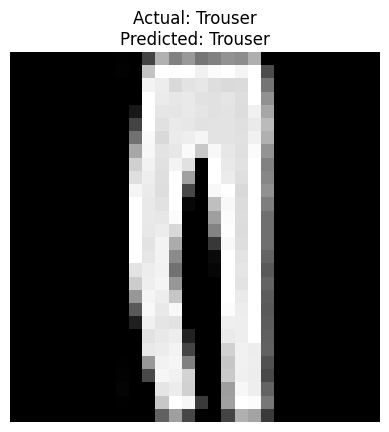

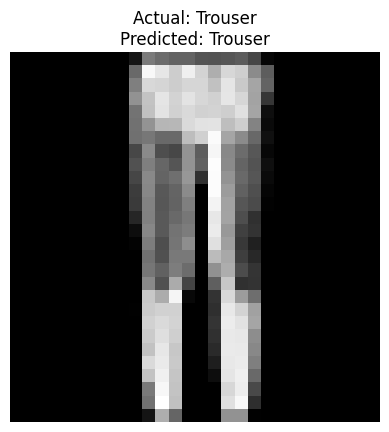

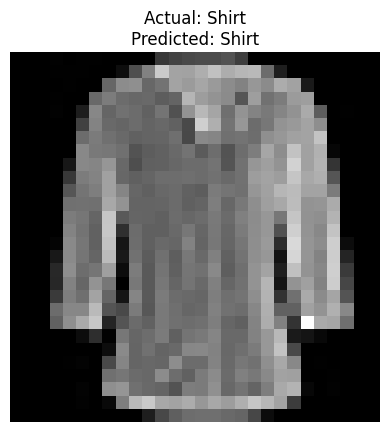

In [11]:
# ============================================
# CELL 10 : SHOW PREDICTIONS
# ============================================

images, labels = next(iter(test_loader))

images_gpu = images.to(device)

outputs = model(images_gpu)

_, predicted = torch.max(outputs, 1)

for i in range(5):

    plt.imshow(images[i].squeeze(), cmap='gray')

    plt.title(
        f"Actual: {classes[labels[i]]}\n"
        f"Predicted: {classes[predicted[i]]}"
    )

    plt.axis('off')

    plt.show()